In [135]:
import scanpy as sc
import os
import numpy as np
import pandas as pd


# 1. Path to your .h5ad file
FILE_PATH = "GSM6061702_GSM6061683.h5ad"  

# --- 1. Load and Light Preprocessing ---
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Could not find {FILE_PATH}")

adata = sc.read_h5ad(FILE_PATH)

In [136]:
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum = 1e4)
# Logarithmize the data
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata)

# --- Custom Parameters ---
ndim = 2           # Number of UMAP dimensions
n_neighbors = 15   # Number of neighbors for the graph
my_res = 1.0       # Clustering resolution (changed from 2.0 to 1.0 as requested)
algo_cluster = "leidenalg"
npca = 50
cluster_key = f'leiden_{my_res}' # Renamed key to reflect global clustering


# 5. Neighbors and UMAP (Step 8)
# This step uses the 50-component PCA result (final_adata.obsm['X_pca'])
print(f"Computing nearest neighbors (k={n_neighbors}) and UMAP (n_dims={ndim})...")
sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep = "X_pca", n_pcs=npca) # Stored in neighboars
sc.tl.umap(adata, n_components=ndim, maxiter=500)

sc.tl.leiden(
    adata,
    flavor=algo_cluster,
    n_iterations=2, # Use n_iterations=2 as in the previous code
    resolution=my_res,
    key_added=cluster_key,
)


Computing nearest neighbors (k=15) and UMAP (n_dims=2)...


In [137]:
adata

AnnData object with n_obs × n_vars = 7489 × 17238
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle', 'leiden_1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_1.0'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

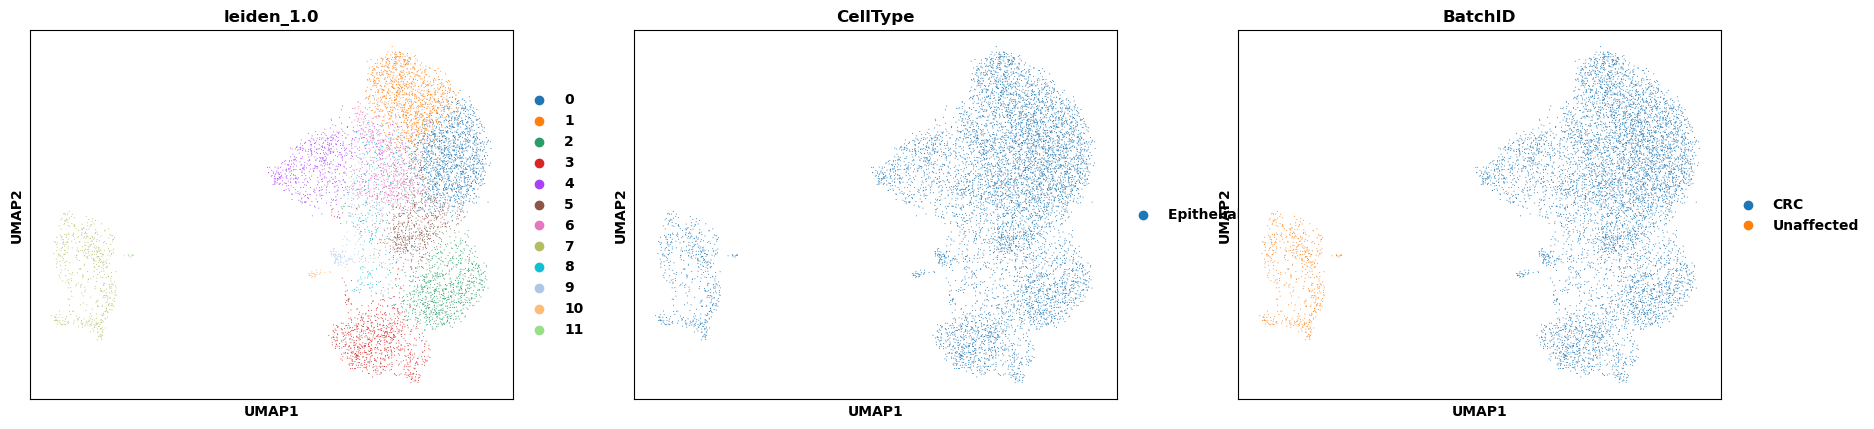

In [138]:
sc.pl.umap(
    adata,
    color=[cluster_key,"CellType", "BatchID"],
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [142]:
def sc_genestat(adata, obs_label, label):
    """
    Compute stats for LINEAR normalized data (no log1p).
    """
    idx = adata.obs[obs_label] == label
    X = adata[idx].X
    if hasattr(X, "toarray"): X = X.toarray()
    
    # 1. No expm1 needed! Work directly on the normalized counts
    u = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    
    # 2. CV calculation (Standard Linear CV)
    cv = np.divide(std, u + 1e-9, out=np.zeros_like(u))
    
    # 3. Dropout (Zeros in normalized data)
    dropr = np.mean(X == 0, axis=0)
    
    # 4. Return the 3D coordinates for the spline (Log-scaling for visualization)
    return pd.DataFrame({
        'lgu': np.log1p(u),    # log1p(mean)
        'lgcv': np.log1p(cv),  # log1p(cv)
        'dropout': dropr 
    }, index=adata.var_names)

In [143]:
# Function result
df_stats = sc_genestat(adata, "BatchID", "CRC")
func_lgu = df_stats.loc["NOC2L", "lgu"]

# Manual Check: CALCULATE LOG OF MEAN correctly
subset_x = adata[adata.obs["BatchID"] == "CRC", "NOC2L"].X
if hasattr(subset_x, "toarray"): subset_x = subset_x.toarray()

manual_u = np.mean(subset_x)
# Step 3: Log it for the plot
manual_lgu_correct = np.log1p(manual_u)

print(f"Function Log-Mean: {func_lgu:.6f}")
print(f"Correct Manual Log-Mean: {manual_lgu_correct:.6f}")

Function Log-Mean: 0.102679
Correct Manual Log-Mean: 0.102679


In [144]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.interpolate import BSpline
from scipy.stats import zscore, norm
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import diags
import matplotlib.pyplot as plt

# --- CORE FUNCTIONS ---

def robust_lsq_solve(A, y, beta=0.5):
    """Solves Ax = y using Iteratively Reweighted Least Squares."""
    u, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    if beta > 0:
        alpha = 0.5 * beta / (1 - beta)
        for _ in range(3):
            res = A @ u - y
            err = res**2
            weights = np.exp(-(alpha / (np.mean(err) + 1e-9)) * err)
            W = diags(weights)
            try:
                lhs = A.T @ W @ A
                rhs = A.T @ W @ y
                u = np.linalg.solve(lhs, rhs)
            except np.linalg.LinAlgError:
                break
    return u
    
def sc_splinefit(adata, obs_label, label, n_pieces=15, beta=0.75):
    """
    Python implementation of MATLAB sc_splinefit with ghost gene filtering.
    """
    # 1. Get stats
    stats = sc_genestat(adata, obs_label, label)
    
    # --- NEW: Filter out genes with zero expression ---
    # If lgu is 0 (mean is 0), the gene is not expressed in this subset.
    # We also filter out any potential NaNs or Infs that could break the cumsum.
    valid_mask = (stats['lgu'] > 0) & stats[['lgu', 'lgcv', 'dropout']].notna().all(axis=1)
    stats = stats[valid_mask].copy()
    
    if stats.empty:
        raise ValueError(f"No valid genes found for label: {label}")
    # --------------------------------------------------
    
    # 2. Sort for parametric arc-length consistency
    stats = stats.sort_values(['lgu', 'lgcv', 'dropout']).reset_index()
    
    lgu = stats['lgu'].values
    lgcv = stats['lgcv'].values
    dropr = stats['dropout'].values
    genes = stats['index'].values 
    
    xyz = np.vstack([lgu, lgcv, dropr]).T
    
    # 3. Compute 's' (Parametric distance)
    # Now that we removed (0,0,0), 's' won't have a massive jump at the start
    diffs = np.diff(xyz, axis=0)
    dists = np.sqrt(np.sum(diffs**2, axis=1))
    s = np.concatenate([[0], np.cumsum(dists)])
    
    # 4. Adaptive n_pieces (Prevents the 'explosion' in small samples)
    # Ensure we don't have more pieces than data points
    actual_n_pieces = min(n_pieces, len(s) // 5)
    
    breaks = np.linspace(s.min(), s.max(), actual_n_pieces + 1)
    k = 3 
    knots = np.concatenate([[breaks[0]]*k, breaks, [breaks[-1]]*k])
    n_basis = len(breaks) + k - 1
    
    # 5. Build Design Matrix
    A = np.zeros((len(s), n_basis))
    for i in range(n_basis):
        coeffs = np.zeros(n_basis)
        coeffs[i] = 1.0
        A[:, i] = BSpline(knots, coeffs, k)(s)

    # 6. Robust Fit
    coef_lgu = robust_lsq_solve(A, lgu, beta=beta)
    coef_cv = robust_lsq_solve(A, lgcv, beta=beta)
    coef_dr = robust_lsq_solve(A, dropr, beta=beta)
    
    xyz1 = np.vstack([A @ coef_lgu, A @ coef_cv, A @ coef_dr]).T
    
    # 7. Nearest Neighbor search
    nn = NearestNeighbors(n_neighbors=1).fit(xyz1)
    dist, near_idx = nn.kneighbors(xyz)
    dist = dist.flatten()
    near_idx = near_idx.flatten()
    
    # 8. Distance weighting (Mirroring MATLAB)
    fitmeanv = xyz1[:, 0]
    x, y = xyz[:, 0], xyz[:, 1]
    final_dist = dist.copy()
    final_dist[x > np.max(fitmeanv)] /= 100
    final_dist[x < np.min(fitmeanv)] /= 10
    residual_cv = y - xyz1[near_idx, 1]
    final_dist[residual_cv < 0] /= 100
    
    T = pd.DataFrame({
        'genes': genes, 'lgu': lgu, 'lgcv': lgcv, 'dropr': dropr,
        'dist': final_dist, 'near_idx': near_idx
    })
    
    return T, xyz, xyz1

In [145]:
crc_spline, crc_xyz, crx_xyz1 = sc_splinefit(adata=adata, obs_label="BatchID", label="CRC", n_pieces=15, beta=0.75)

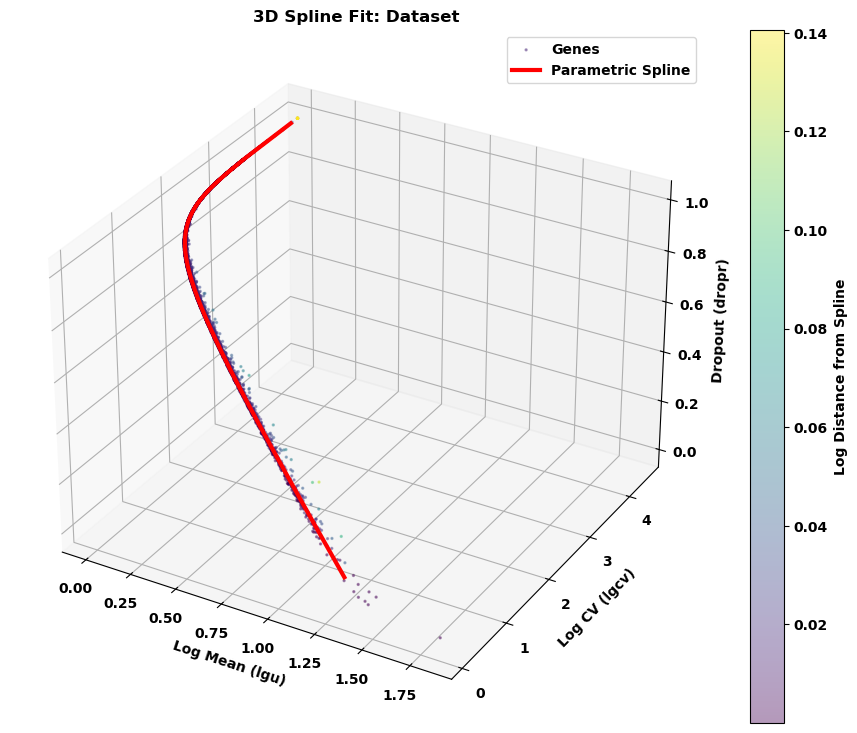

In [146]:
from mpl_toolkits.mplot3d import Axes3D

def plot_spline(T, xyz, xyz1, label="Dataset"):
    """
    Visualizes the 3D gene cloud and the parametric spline fit.
    Colors the genes by their distance (residual) from the spline.
    """
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Scatter the genes
    # We use a log-transform on distance for the color scale to highlight outliers
    scatter = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                         c=np.log1p(T['dist']), cmap='viridis', 
                         s=2, alpha=0.4, label='Genes')

    # 2. Plot the fitted spline curve
    ax.plot(xyz1[:, 0], xyz1[:, 1], xyz1[:, 2], 
            color='red', linewidth=3, label='Parametric Spline', zorder=10)

    # 3. Labeling
    ax.set_title(f"3D Spline Fit: {label}")
    ax.set_xlabel('Log Mean (lgu)')
    ax.set_ylabel('Log CV (lgcv)')
    ax.set_zlabel('Dropout (dropr)')
    
    fig.colorbar(scatter, ax=ax, label='Log Distance from Spline')
    ax.legend()
    plt.show()


plot_spline(crc_spline, crc_xyz, crx_xyz1)

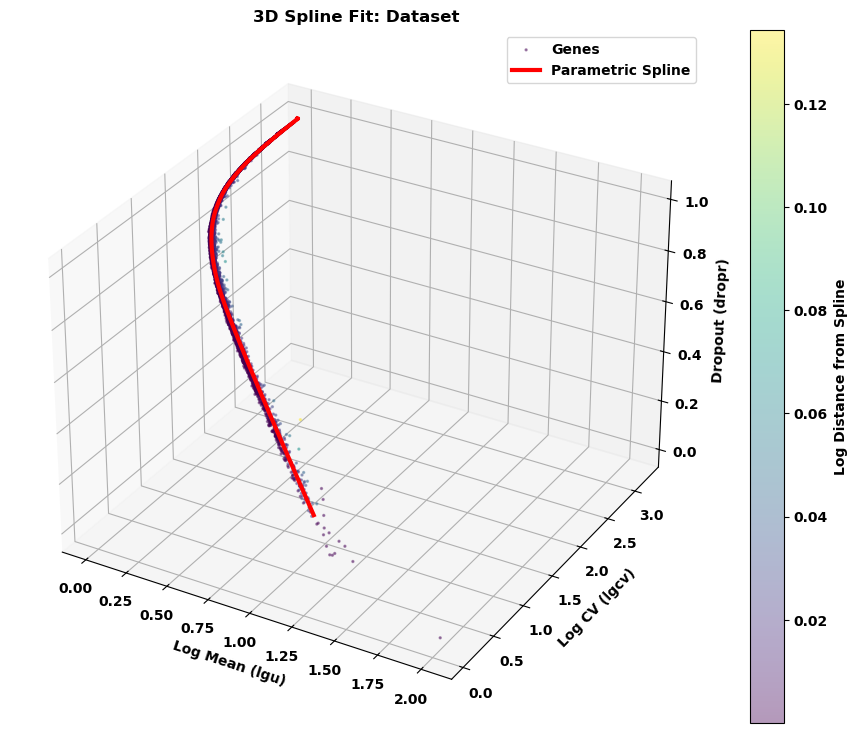

In [147]:
crc_spline, crc_xyz, crx_xyz1 = sc_splinefit(adata=adata, obs_label="BatchID", label="Unaffected", n_pieces=15, beta=0.75)
plot_spline(crc_spline, crc_xyz, crx_xyz1)

In [150]:
import scanpy as sc
import numpy as np

def sc_qcfilter(adata, libsize=1000, mtratio=0.15, min_cells_nonzero=15, inplace=False):
    """
    Mimics the MATLAB qcfilter/sc_qcfilter logic.
    Filters cells by library size and MT-content, and genes by minimum prevalence.
    """
    ad = adata if inplace else adata.copy()

    # 1. Identify Mitochondrial Genes
    # We look for genes starting with MT- (human) or mt- (mouse)
    ad.var['mt'] = ad.var_names.str.startswith(('MT-', 'mt-'))
    
    # 2. Calculate QC Metrics (Total counts and MT fraction)
    sc.pp.calculate_qc_metrics(ad, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

    # 3. Filter Cells: Library Size (total_counts) and MT Ratio (pct_counts_mt / 100)
    # MATLAB mtratio 0.15 = Scanpy pct_counts_mt 15.0
    cell_mask = (ad.obs['total_counts'] >= libsize) & (ad.obs['pct_counts_mt'] <= mtratio * 100)
    ad = ad[cell_mask, :].copy()

    # 4. Filter Genes: Minimum cells with non-zero expression
    sc.pp.filter_genes(ad, min_cells=min_cells_nonzero)

    return ad

def sc_splinedv(adata1, adata2, obs_label, cond_1, cond_2, fname=None, plotit=False, beta=0.75):
    """
    Calculates differential variability and mean difference (Cond 2 - Cond 1).
    Matches MATLAB output: includes mean_diff, dist_sign, dv_score, z_score, pval.
    """
    # 1. Fit splines independently
    T1, xyz1, xyzp1 = sc_splinefit(adata1, obs_label, cond_1, beta=beta)
    T2, xyz2, xyzp2 = sc_splinefit(adata2, obs_label, cond_2, beta=beta)

    # 2. Intersection of genes
    common_genes = np.intersect1d(T1['genes'], T2['genes'])
    
    # 3. Align and Sort
    T1_filt = T1.set_index('genes').loc[common_genes].sort_index().reset_index()
    T2_filt = T2.set_index('genes').loc[common_genes].sort_index().reset_index()
    
    # 4. Extract aligned 3D coordinates
    xyz1_aligned = np.vstack([T1_filt.lgu, T1_filt.lgcv, T1_filt.dropr]).T
    xyz2_aligned = np.vstack([T2_filt.lgu, T2_filt.lgcv, T2_filt.dropr]).T

    # 5. Vector Residuals (v = actual - spline_projection)
    v1 = xyz1_aligned - xyzp1[T1_filt['near_idx'].values]
    v2 = xyz2_aligned - xyzp2[T2_filt['near_idx'].values]

    # 6. DV Calculation (Condition 2 - Condition 1)
    d1 = T1_filt['dist'].values
    d2 = T2_filt['dist'].values

    # Magnitude of the 3D shift between residuals with direction
    dist_diff_magnitude = np.linalg.norm(v2 - v1, axis=1)
    dist_sign = np.sign(d2 - d1) # (+) means Cond 2 is further from its spline
    dist_diff_signed = dist_diff_magnitude * dist_sign
    
    # Mean Difference
    mean_diff = T2_filt['lgu'].values - T1_filt['lgu'].values
    
    # Statistics
    z_scores = zscore(dist_diff_signed)
    pval = 2 * (1 - norm.cdf(np.abs(z_scores)))

    # 7. Dynamic Column Naming
    sfx1 = f"_{cond_1.replace(' ', '_')}"
    sfx2 = f"_{cond_2.replace(' ', '_')}"

    # Merge into final Tdv table
    Tdv = pd.concat([
        T1_filt.drop(columns=['near_idx']).add_suffix(sfx1), 
        T2_filt.drop(columns=['near_idx', 'genes']).add_suffix(sfx2),
        pd.DataFrame({
            'mean_diff': mean_diff,
            'dist_sign': dist_sign,       # Crucial for enrichment logic
            'dv_score': dist_diff_signed, 
            'z_score': z_scores,
            'pval': pval
        })
    ], axis=1).rename(columns={f'genes{sfx1}': 'gene'})

    # 8. Boundary Protection
    max_idx1, max_idx2 = T1_filt['near_idx'].max(), T2_filt['near_idx'].max()
    idxx = (T1_filt['near_idx'] <= 1) | (T2_filt['near_idx'] <= 1) | \
           (T1_filt['near_idx'] == max_idx1) | (T2_filt['near_idx'] == max_idx2)
    
    Tdv.loc[idxx, ['dist_sign', 'dv_score', 'z_score']] = 0

    # Sort by the most increased variability in Condition 2
    Tdv = Tdv.sort_values("dv_score", ascending=False)
    
    if fname:
        Tdv.to_csv(f"{fname}_diff_var.csv", index=False)

    if plotit:
            import matplotlib.pyplot as plt
            from mpl_toolkits.mplot3d import Axes3D

            fig = plt.figure(figsize=(12, 8))
            ax = fig.add_subplot(111, projection='3d')

            # 1. Plot Condition 1: Blue spline + Cyan-ish dots
            ax.scatter(xyz1_aligned[:,0], xyz1_aligned[:,1], xyz1_aligned[:,2], 
                    s=20, edgecolors='c', facecolors='none', alpha=0.2, 
                    label=f'{cond_1} Stats')
            ax.plot(xyzp1[:,0], xyzp1[:,1], xyzp1[:,2], 
                    'b-', linewidth=3, label=f'{cond_1} Spline')

            # 2. Plot Condition 2: Red spline + Green-ish dots
            ax.scatter(xyz2_aligned[:,0], xyz2_aligned[:,1], xyz2_aligned[:,2], 
                    s=20, edgecolors='g', facecolors='none', alpha=0.2, 
                    label=f'{cond_2} Stats')
            ax.plot(xyzp2[:,0], xyzp2[:,1], xyzp2[:,2], 
                    'r-', linewidth=3, label=f'{cond_2} Spline')

            # 3. Highlight Top Genes (Optional but very helpful)
            # Take the top 5 genes by dv_score to show on the plot
            top_genes = Tdv.head(5)
            for _, row in top_genes.iterrows():
                ax.text(row[f'lgu_{cond_2.replace(" ","_")}'], 
                        row[f'lgcv_{cond_2.replace(" ","_")}'], 
                        row[f'dropr_{cond_2.replace(" ","_")}'], 
                        row['gene'], color='black', fontsize=9, fontweight='bold')

            # Formatting
            ax.set_title(f'Differential Variability: {cond_1} vs {cond_2}')
            ax.set_xlabel('Log1p Mean')
            ax.set_ylabel('Log1p CV')
            ax.set_zlabel('Dropout Rate')
            
            # Adjust view angle for better depth perception
            ax.view_init(elev=20, azim=45)
            
            ax.legend()
            plt.tight_layout()
            plt.show()

    return Tdv

def run_splinedv_on_adata(adata, cell_type_col, cell_type, condition_col, cond_1, cond_2, 
                          do_qc=True, qc_params=None, min_info_cells=5, **kwargs):
    """
    Production-grade Python wrapper for DV Analysis.
    Matches MATLAB's callback logic: Info Gene Selection -> Partition -> QC -> Spline.
    """
    # --- STEP 1: Select Informative Genes (gui.i_selectinfogenes) ---
    # We remove genes that are almost never expressed in this cell type
    a_count = adata.n_vars
    sc.pp.filter_genes(adata, min_cells=min_info_cells)
    b_count = adata.n_vars
    print(f"Informative Gene Selection: {a_count - b_count} genes removed.")

    # --- STEP 2: Partition by Cell Type ---
    ad_ct = adata[adata.obs[cell_type_col] == cell_type].copy()
    
    # --- STEP 3: Partition by Condition ---
    a1 = ad_ct[ad_ct.obs[condition_col] == cond_1].copy()
    a2 = ad_ct[ad_ct.obs[condition_col] == cond_2].copy()
    
    # --- STEP 4: Independent QC (sce.qcfilter) ---
    if do_qc:
        params = {'libsize': 1000, 'mtratio': 0.15, 'min_cells_nonzero': 15}
        if qc_params: params.update(qc_params)
        
        print(f"QC Filtering {cond_1}...")
        a1 = sc_qcfilter(a1, **params)
        print(f"QC Filtering {cond_2}...")
        a2 = sc_qcfilter(a2, **params)

    # Check for minimum data requirements
    if a1.n_obs < 10 or a2.n_obs < 10:
        print("Error: Too few cells/genes after filtering.")
        return None

    # --- STEP 5: Run Spline Fit Analysis ---
    Tdv = sc_splinedv(a1, a2, condition_col, cond_1, cond_2, **kwargs)
    
    return Tdv, a1, a2

Informative Gene Selection: 0 genes removed.
QC Filtering Unaffected...
QC Filtering CRC...


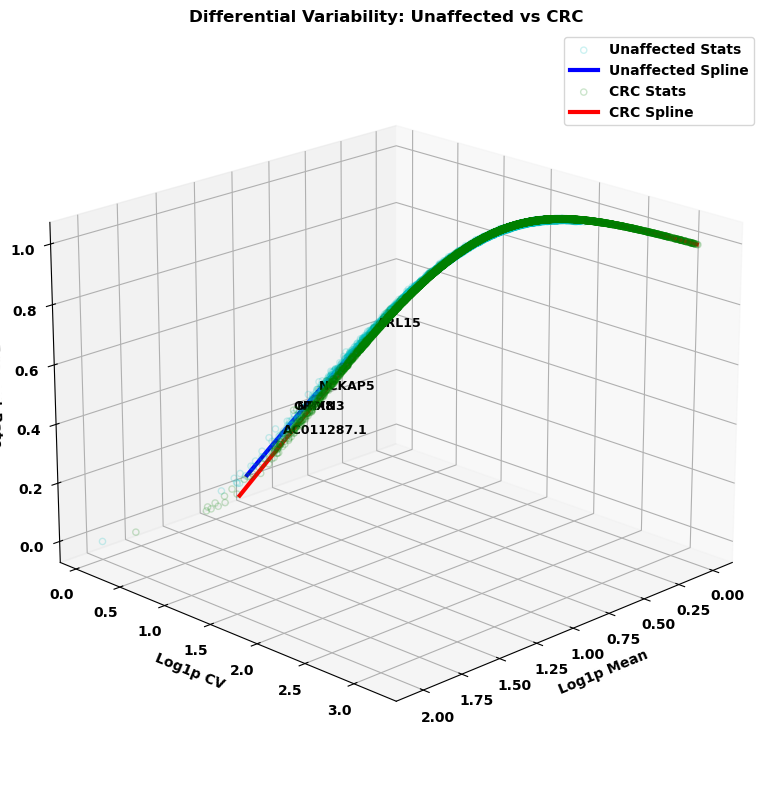

In [ ]:
results, adata1, adata2 = run_splinedv_on_adata(
    adata,
    cell_type_col = 'CellType',
    cell_type     = 'Epithelial cells',
    condition_col = 'BatchID',
    cond_1        = 'Unaffected',
    cond_2        = 'CRC',
    do_qc         = True,
    qc_params     = {'libsize': 1000, 'mtratio': 0.15, 'min_cells_nonzero': 15},
    fname         = 'results/epithelial_spline', 
    plotit        = True,
    beta          = 0.5
)

In [152]:
# Display top genes where CRC is more variable than Unaffected
print(results.sort_values('dv_score', ascending=False).head(10))

            gene  lgu_Unaffected  lgcv_Unaffected  dropr_Unaffected  \
4912       NRXN3        0.133086         1.536101          0.923077   
3063        GRM8        0.278087         1.303063          0.865832   
102   AC011287.1        0.266534         1.222312          0.840787   
4697      NCKAP5        0.448977         0.983938          0.717352   
696        ARL15        1.062277         0.483358          0.250447   
6158       ROBO2        0.048536         1.945407          0.967800   
8599      ZSWIM6        1.135589         0.433652          0.196780   
4197       MBNL1        1.222585         0.387788          0.152057   
3850        LGR5        0.094452         1.764445          0.957066   
2947     GMDS-DT        1.112436         0.455248          0.221825   

      dist_Unaffected   lgu_CRC  lgcv_CRC  dropr_CRC  dist_CRC  mean_diff  \
4912         0.006252  1.040990  0.580567   0.339827  0.102045   0.907904   
3063         0.057438  1.071807  0.596906   0.345310  0.135274  